In [1]:
import glob
import torch
import warnings
import numpy as np
import pop_tools
import xesmf as xe
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from engression.models import Net
from engression import engression
from dask.distributed import Client
from concurrent.futures import ProcessPoolExecutor

In [2]:
# ------------------------------
# Settings
# ------------------------------

# Set seed
torch.manual_seed(0)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ignore port warning
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

# Load grids
low_grid = pop_tools.get_grid('POP_gx1v7')
low_grid['TAREA'] = low_grid['TAREA'] / 1e4
low_grid['TAREA'].attrs['units'] = 'm^2'

high_grid = xr.open_dataset('/glade/p/cesmdata/cseg/inputdata/share/domains/domain.ocn.tx0.1v2.161014.nc')
high_grid['tarea'] = high_grid['area'] / 1e4
high_grid['tarea'].attrs['units'] = 'm^2'

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 200)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Plotting
cmap = plt.colormaps['Blues']
plt.rcParams["figure.figsize"] = [6, 6]

# Files
low_res_dirs = sorted(glob.glob('/gdex/data/d651030/BHIST/*ihesp-hires*'))
high_res_dirs = sorted(glob.glob('/gdex/data/d651007/*ihesp-hires*'))

low_vars = ['hi', 'Tsfc', 'uvel', 'vvel']
target_var = ['hi']

bbox = {"lon_min": -115, "lon_max": -95, "lat_min": 66, "lat_max": 73}
lon_min = -115 % 360
lon_max = -95 % 360

comp_map = {
    'hi': 'ice',
    'Tsfc': 'ice',
    'uvel': 'ice',
    'vvel': 'ice',
}

# Set up client
client = Client(n_workers=1, threads_per_worker=8, memory_limit='60GB')
print("If on NCAR, copy and paste this link into the Dask Dashboard tab:")
print(client.dashboard_link)
print("\nDevice:", device)

If on NCAR, copy and paste this link into the Dask Dashboard tab:
https://jupyterhub.hpc.ucar.edu/stable/user/skygale/proxy/34597/status

Device: cpu


## Set up training and testing data

In [7]:
# ------------------------------
# File Collection
# ------------------------------
def collect_files(dirs, vars):
    out = []
    for d in dirs:
        member_files = {}
        for v in vars:
            pattern = f"{d}/ice/proc/tseries/month_1/*.{v}.*.nc"
            member_files[v] = sorted(glob.glob(pattern))
        out.append(member_files)
    return out


low_res_files = collect_files(low_res_dirs, low_vars)
high_res_files = collect_files(high_res_dirs, target_var)

print('Low-res  | # ensembles:', len(low_res_files), '| # variables:', len(low_res_files[0]))
print('High-res | # ensembles:', len(high_res_files), '| # variables:', len(high_res_files[0]))

Low-res  | # ensembles: 9 | # variables: 4
High-res | # ensembles: 9 | # variables: 1


In [25]:
# ------------------------------
# Precompute spatial masks
# ------------------------------
mask = (
    (low_grid['TLAT'] >= bbox["lat_min"]) &
    (low_grid['TLAT'] <= bbox["lat_max"]) &
    (low_grid['TLONG'] >= lon_min) &
    (low_grid['TLONG'] <= lon_max)
)

land_mask = (low_grid['REGION_MASK'] != 0)
land_mask = land_mask.where(mask, drop=True).values
land_mask = np.nan_to_num(land_mask, nan=0.0)


# ------------------------------
# Worker Function
# ------------------------------
def process_file(args):

    file, varname = args
    ds = xr.open_dataset(file)

    da = ds[varname].rename({'nj': 'nlat', 'ni': 'nlon'})
    da_masked = da.where(mask, drop=True)
    arr = np.nan_to_num(da_masked.values, nan=0.0).astype(np.float32)

    ds.close()

    return arr


# ------------------------------
# Parallelized Extraction Function
# ------------------------------
def load_variable(file_list, varname):

    args = [(f, varname) for f in file_list]

    with ProcessPoolExecutor(max_workers=1) as exe:
        data = list(exe.map(process_file, args))

    return np.concatenate(data, axis=0)  # (time, lat, lon)


# ------------------------------
# Build X (Low-Res Predictors)
# ------------------------------
X_list = []

for i, member in enumerate(low_res_files):
    channels = []

    print(f"Processing Ensemble #{i+1}...")

    for var in low_vars:
        var_data = load_variable(member[var], var)   # (time, lat, lon)
        channels.append(var_data)

    channels = np.stack(channels, axis=1)  # (time, channels, lat, lon)

    # Add land mask channel
    mask_channel = np.broadcast_to(
        land_mask,
        (channels.shape[0], 1, *land_mask.shape)
    )

    member_tensor = np.concatenate([channels, mask_channel], axis=1)

    # print("  tensor:", member_tensor.shape)
    X_list.append(member_tensor)

# Final stack
X = np.stack(X_list, axis=0)

print("\nFinal X shape:", X.shape)
print("land_mask    :", land_mask.shape)

Processing Ensemble #1...
Processing Ensemble #2...
Processing Ensemble #3...
Processing Ensemble #4...
Processing Ensemble #5...
Processing Ensemble #6...
Processing Ensemble #7...
Processing Ensemble #8...
Processing Ensemble #9...

Final X shape: (9, 1032, 5, 19, 26)
land_mask    : (19, 26)


In [27]:
# Save
X_to_save = xr.Dataset(
    {"X":
     (("ensemble", "time", "channel", "lat", "lon"),
      X)}
)
X_to_save.to_netcdf('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_training.nc')

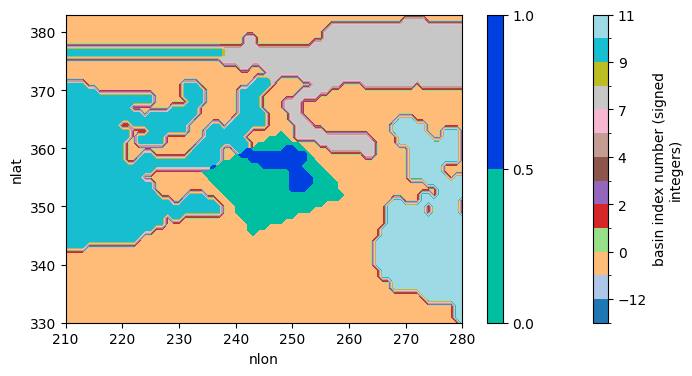

In [29]:
regions = np.array(np.unique(low_grid.REGION_MASK))

test = (low_grid['REGION_MASK'] != 0)
test_mask = test.where(mask)

plt.figure(figsize=(8, 4))
low_grid.REGION_MASK.plot.contourf(levels=regions, cmap='tab20')
im = plt.contourf(test_mask, levels=np.linspace(0, 1, 3), cmap='winter_r')
plt.colorbar(im)
plt.xlim(210, 280)
plt.ylim(330, 383)
plt.show()

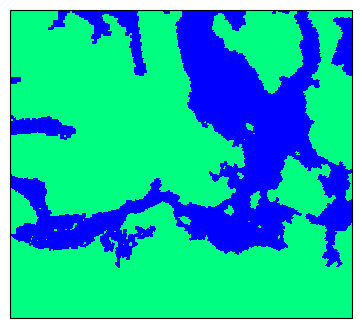

In [31]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(central_longitude=-105, central_latitude=69))
ax.set_extent([-115, -95, 66, 73], crs=ccrs.PlateCarree())
ax.pcolormesh(high_grid['xc'], high_grid['yc'], high_grid.mask.values, cmap='winter_r', transform=ccrs.PlateCarree())
plt.show()

In [10]:
# ------------------------------
# Precompute spatial mask
# ------------------------------
mask = (
    (high_grid['yc'] >= bbox["lat_min"]) &
    (high_grid['yc'] <= bbox["lat_max"]) &
    (high_grid['xc'] >= lon_min) &
    (high_grid['xc'] <= lon_max)
)

# Land mask
Y_land_mask = high_grid['mask'].where(mask, drop=True).values

# Regridder
lat = high_grid["yc"].values
rows_60 = np.where(np.any(lat >= 60, axis=1))[0]

jmin = rows_60.min()
jmax = rows_60.max()

# Regrid
ds_src = xr.Dataset({
    "lat": (["nj", "ni"], high_grid["yc"].isel(nj=slice(jmin, jmax)).values),
    "lon": (["nj", "ni"], high_grid["xc"].isel(nj=slice(jmin, jmax)).values),
})

ds_out = xr.Dataset({
    "lat": (["lat"], np.arange(60, 90, 0.1)),
    "lon": (["lon"], np.arange(0, 360, 0.1)),
})

regridder = xe.Regridder(
    ds_src, ds_out,
    "bilinear",
    periodic=True,
    filename="tripole_to_latlon_60N_weights.nc",
    reuse_weights=True,
)


# ------------------------------
# Worker Function
# ------------------------------
def process_file_hires(file):

    ds = xr.open_dataset(file)
    da = ds[target_var[0]]

    # Use same subset as regridder
    da = da.isel(nj=slice(jmin, jmax))

    # Regrid
    da_reg = regridder(da)

    # Subset final lat-lon region
    da_masked = da_reg.sel(
        lat=slice(bbox["lat_min"], bbox["lat_max"]),
        lon=slice(lon_min, lon_max)
    )

    arr = np.nan_to_num(da_masked.values, nan=0.0).astype(np.float32)

    ds.close()

    return arr


# ------------------------------
# Parallelized Extraction Function
# ------------------------------
def load_variable(file_list):

    with ProcessPoolExecutor(max_workers=1) as exe:
        data = list(exe.map(process_file_hires, file_list))

    return np.concatenate(data, axis=0)  # (time, lat, lon)


# ------------------------------
# Build Y (High-Res Target)
# ------------------------------
Y_list = []

for i, member in enumerate(high_res_files):

    print(f"Processing Ensemble #{i+1}...")

    var_data = load_variable(member[target_var[0]])

    print("  tensor:", var_data.shape)
    Y_list.append(var_data)

# Final stack
Y = np.stack(Y_list, axis=0)

# Add channels dimension
Y = Y[:, np.newaxis, :, :]
Y = np.swapaxes(Y, 1, 2)

print("Final Y shape:", Y.shape)
print("Y_land_mask  :", Y_land_mask.shape)

Processing Ensemble #1...
  tensor: (1032, 70, 201)
Processing Ensemble #2...
  tensor: (1032, 70, 201)
Processing Ensemble #3...
  tensor: (1032, 70, 201)
Processing Ensemble #4...
  tensor: (1032, 70, 201)
Processing Ensemble #5...
  tensor: (1032, 70, 201)
Processing Ensemble #6...
  tensor: (1032, 70, 201)
Processing Ensemble #7...
  tensor: (1032, 70, 201)
Processing Ensemble #8...
  tensor: (1032, 70, 201)
Processing Ensemble #9...
  tensor: (1032, 70, 201)
Final Y shape: (9, 1, 1032, 70, 201)
Y_land_mask  : (207, 460)


In [13]:
# Save
Y_to_save = xr.Dataset(
    {"Y":
     (("ensemble", "time", "channel", "lat", "lon"),
      Y)}
)
Y_to_save.to_netcdf('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_training.nc')

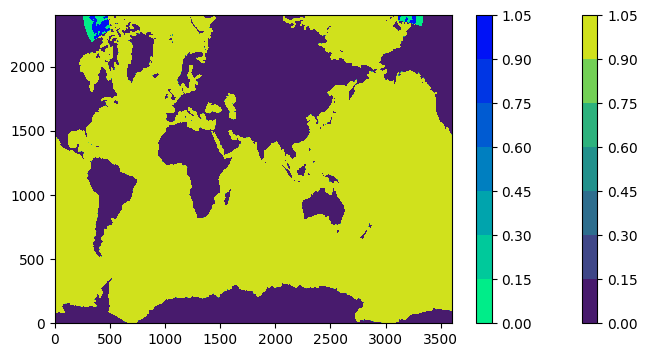

In [37]:
mask = (
    (high_grid['yc'] >= bbox["lat_min"]) &
    (high_grid['yc'] <= bbox["lat_max"]) &
    (high_grid['xc'] >= lon_min) &
    (high_grid['xc'] <= lon_max)
)

Y_test_mask = high_grid['mask'].where(mask)

plt.figure(figsize=(8, 4))
plt.contourf(high_grid.mask)
plt.colorbar()
plt.contourf(Y_test_mask, cmap='winter_r')
plt.colorbar()
plt.show()

In [3]:
X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_training.nc').X.values
Y = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/Y_training.nc').Y.values
X.shape, Y.shape

((9, 1032, 5, 19, 26), (9, 1032, 1, 70, 201))

## Engression Model

In [9]:
# ------------------------------
# Set up regridding
# ------------------------------
TLONG = ((low_grid.TLONG + 180) % 360) - 180

# Mask grids
mask = (
    (TLONG >= bbox["lon_min"]) &
    (TLONG <= bbox["lon_max"]) &
    (low_grid.TLAT >= bbox["lat_min"]) &
    (low_grid.TLAT <= bbox["lat_max"])
)
low_grid_sub = low_grid.where(mask, drop=True)

mask_high = (
    (high_grid.xc >= lon_min) &
    (high_grid.xc <= lon_max) &
    (high_grid.yc >= bbox["lat_min"]) &
    (high_grid.yc <= bbox["lat_max"])
)
high_grid_sub = high_grid.where(mask_high, drop=True)

# Source grid
ds_src = xr.Dataset({
    "lat": (("nlat", "nlon"), low_grid_sub.TLAT.values),
    "lon": (("nlat", "nlon"), TLONG.where(mask, drop=True).values),
})

# Destination grid
ds_dst = xr.Dataset({
    "lat": (("nj", "ni"), high_grid_sub.yc.values),
    "lon": (("nj", "ni"), high_grid_sub.xc.values),
})

# Create regridders
# Continuous
regridder_bilinear = xe.Regridder(
    ds_src,
    ds_dst,
    method="bilinear",
    periodic=False
)

# Land mask
regridder_nearest = xe.Regridder(
    ds_src,
    ds_dst,
    method="nearest_s2d"
)

# ------------------------------
# Interpolation
# ------------------------------
X_interp_list = []

for m in range(X.shape[0]):

    member_channels = []

    # Continuous predictors
    for i in range(5):
        da = xr.DataArray(
            X[m, i],
            dims=("nlat", "nlon")
        )
        da_interp = regridder_bilinear(da)
        member_channels.append(da_interp.values)

    # Land mask (nearest)
    da_land = xr.DataArray(
        X[m, 5],
        dims=("nlat", "nlon")
    )
    land_interp = regridder_nearest(da_land)
    member_channels.append(land_interp.values)

    member_stack = np.stack(member_channels, axis=0)
    X_interp_list.append(member_stack)

X_hr = np.stack(X_interp_list, axis=0)[:, :5]  # drop land channel for now

print("X_hr shape:", X_hr.shape)

X_hr shape: (9, 5, 207, 460)


In [14]:
# Flatten
N_ens, C, H, W = X_hr.shape
X_flat = X_hr.reshape(N_ens, C, -1)
Y_flat = Y.reshape(N_ens, 1, -1)

# Mask
ocean_mask = (high_grid_sub.mask.values == 1)
ocean_flat = ocean_mask.flatten()
X_flat = X_flat[:, :, ocean_flat]
Y_flat = Y_flat[:, :, ocean_flat]

# Split by ensemble member
n_ens = X_flat.shape[0]
C = X_flat.shape[1]

test_member = np.random.choice(n_ens)
train_members = [i for i in range(n_ens) if i != test_member]

print("Test member:", test_member)

# Reshape
X_train_np = (X_flat[train_members].transpose(0, 2, 1).reshape(-1, C))
Y_train_np = (Y_flat[train_members].transpose(0, 2, 1).reshape(-1, 1))
X_test_np = X_flat[test_member].T
Y_test_np = Y_flat[test_member].T

# Standardize (TRAINING STATS ONLY)
X_mean = X_train_np.mean(axis=0)
X_std = X_train_np.std(axis=0)
X_std[X_std == 0] = 1.0
X_train_np = (X_train_np - X_mean) / X_std
X_test_np = (X_test_np - X_mean) / X_std

print("X_train:", X_train_np.shape)
print("Y_train:", Y_train_np.shape)
print("X_test :", X_test_np.shape)
print("Y_test :", Y_test_np.shape)

Test member: 3
X_train: (97840, 5)
Y_train: (97840, 1)
X_test : (12230, 5)
Y_test : (12230, 1)


In [15]:
# Convert to torch and move to GPU
X_train = torch.tensor(X_train_np, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train_np, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test_np, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test_np, dtype=torch.float32).to(device)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: torch.Size([97840, 5])
Y_train: torch.Size([97840, 1])
X_test: torch.Size([12230, 5])
Y_test: torch.Size([12230, 1])


In [18]:
# Final checks
print(torch.isnan(X_train).sum())
print(torch.isnan(Y_train).sum())
print(X_train.mean(0))
print(X_train.std(0))

tensor(0)
tensor(0)
tensor([ 1.1977e-07, -4.9906e-09,  1.7467e-08, -2.4953e-09, -6.6126e-08])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [22]:
# Fit an engression model
engressor = engression(
    X_train,
    Y_train,
    lr=0.005,
    num_epochs=500,
    batch_size=2048,
    device=device
)

Running on CPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 2048.
[Epoch 1 (0%), batch 47] energy-loss: 0.4654,  E(|Y-Yhat|): 0.8789,  E(|Yhat-Yhat'|): 0.8270
[Epoch 100 (20%), batch 47] energy-loss: 0.3810,  E(|Y-Yhat|): 0.7709,  E(|Yhat-Yhat'|): 0.7799
[Epoch 200 (40%), batch 47] energy-loss: 0.3728,  E(|Y-Yhat|): 0.7507,  E(|Yhat-Yhat'|): 0.7558
[Epoch 300 (60%), batch 47] energy-loss: 0.3726,  E(|Y-Yhat|): 0.7580,  E(|Yhat-Yhat'|): 0.7708
[Epoch 400 (80%), batch 47] energy-loss: 0.3648,  E(|Y-Yhat|): 0.7480,  E(|Yhat-Yhat'|): 0.7664
[Epoch 500 (100%), batch 47] energy-loss: 0.3654,  E(|Y-Yhat|): 0.7375,  E(|Yhat-Yhat'|): 0.7443

Training loss on the original (non-standardized) scale:
	Energy-loss: 0.3232,  E(|Y-Yhat|): 0.6576,  E(|Yhat-Yhat'|): 0.6688

Pre

In [23]:
engressor.summary()

Engression model with
	 number of layers: 2
	 hidden dimensions: 100
	 noise dimensions: 100
	 residual blocks: False
	 number of epochs: 500
	 batch size: 2048
	 learning rate: 0.005
	 standardization: True
	 training mode: False
	 device: cpu

Training loss (original scale):
	 energy-loss: 0.32, 
	E(|Y-Yhat|): 0.66, 
	E(|Yhat-Yhat'|): 0.67


In [28]:
# Evaluation
mse = engressor.eval_loss(X_test, Y_test, loss_type="l2")
print("L2 loss:", mse)
print("RMSE:", mse**0.5)

print(
    "correlation between predicted and true means:",
    engressor.eval_loss(X_test, Y_test, loss_type="cor")
)

L2 loss: 0.8069546222686768
RMSE: 0.898306530238246
correlation between predicted and true means: 0.34430399537086487


In [29]:
# Predictions
Y_pred_test = engressor.predict(X_test)

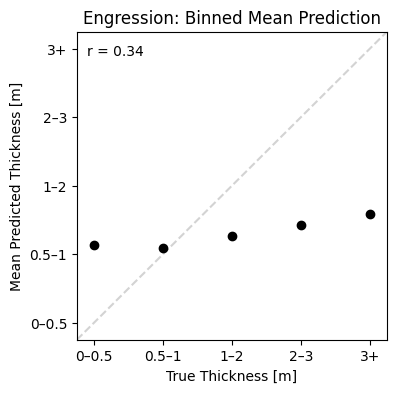

In [87]:
bin_centers = []
mean_pred = []

bins = [0, 0.5, 1.0, 2.0, 3.0, 10]  # meters
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

y_true = Y_test.cpu().numpy().flatten()
y_pred = Y_pred_test.detach().cpu().numpy().flatten()
true_cat = np.digitize(y_true, bins)
pred_cat = np.digitize(y_pred, bins)

for i in range(1, len(bins)):
    mask = (y_true >= bins[i-1]) & (y_true < bins[i])
    if np.sum(mask) > 0:
        bin_centers.append(np.mean(y_true[mask]))
        mean_pred.append(np.mean(y_pred[mask]))

plt.figure(figsize=(4, 4))
plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
plt.scatter(labels, mean_pred, color='k', marker="o", zorder=3)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel("True Thickness [m]")
plt.ylabel("Mean Predicted Thickness [m]")
plt.title("Engression: Binned Mean Prediction")
plt.text(-0.1, 3.9, "r = 0.34")
plt.xlim(-0.25, 4.25)
plt.ylim(-0.25, 4.25)
plt.show()

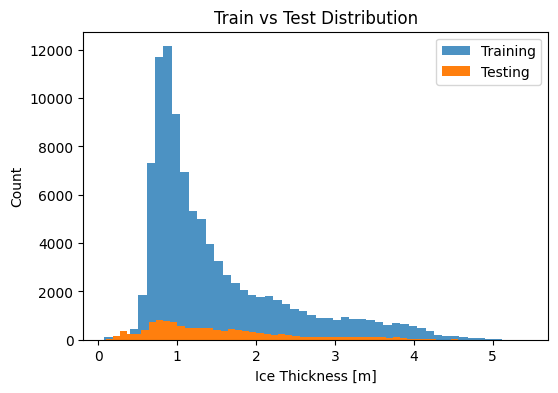

In [46]:
y_train = Y_train.cpu().numpy().flatten()

plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=50, alpha=0.8, label="Training")
plt.hist(y_true, bins=50, label="Testing")
plt.xlabel("Ice Thickness [m]")
plt.ylabel("Count")
plt.legend()
plt.title("Train vs Test Distribution")
plt.show()

In [66]:
# Define model
num_features = X_train.shape[1]
model = Net(num_layer=2, hidden_dim=100, in_dim=num_features).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# Training loop (batched)
num_epochs = 500
batch_size = 2048
n_samples = X_train.shape[0]

for epoch in range(num_epochs):
    perm = torch.randperm(n_samples)
    for i in range(0, n_samples, batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = Y_train[idx]

        opt.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        opt.step()

    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            train_loss = criterion(model(X_train), Y_train).item()
            test_loss = criterion(model(X_test), Y_test).item()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Predictions
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

rmse_test = torch.sqrt(criterion(y_pred_test, Y_test))
corr_test = np.corrcoef(Y_test.cpu().numpy().flatten(), y_pred_test.cpu().numpy().flatten())[0, 1]
print("Test RMSE:", rmse_test.item())
print("Test correlation:", corr_test)

Epoch 50/500 | Train Loss: 0.4220 | Test Loss: 0.7027
Epoch 100/500 | Train Loss: 0.4027 | Test Loss: 0.8073
Epoch 150/500 | Train Loss: 0.3791 | Test Loss: 0.8491
Epoch 200/500 | Train Loss: 0.3691 | Test Loss: 0.8336
Epoch 250/500 | Train Loss: 0.3597 | Test Loss: 0.8336
Epoch 300/500 | Train Loss: 0.3571 | Test Loss: 0.8411
Epoch 350/500 | Train Loss: 0.3530 | Test Loss: 0.8713
Epoch 400/500 | Train Loss: 0.3475 | Test Loss: 0.8832
Epoch 450/500 | Train Loss: 0.3533 | Test Loss: 0.9030
Epoch 500/500 | Train Loss: 0.3402 | Test Loss: 0.9396
Test RMSE: 0.9693542718887329
Test correlation: 0.19282535083396346


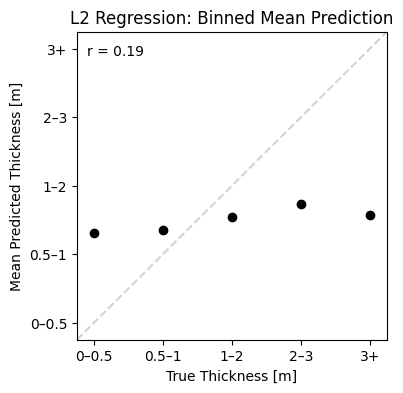

In [89]:
def plot_binned_predictions(y_true, y_pred, bins, labels):
    y_true = y_true.cpu().numpy().flatten()
    y_pred = y_pred.cpu().numpy().flatten()

    # Mean prediction per bin
    y_pred_mean = []
    for i in range(len(bins)-1):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.any():
            y_pred_mean.append(y_pred[mask].mean())
        else:
            y_pred_mean.append(np.nan)

    # Plot
    plt.figure(figsize=(4, 4))
    plt.plot([-0.25, 4.25], [-0.25, 4.25], color='lightgrey', linestyle='--')
    plt.scatter(labels, y_pred_mean, color="k", marker='o')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel("True Thickness [m]")
    plt.ylabel("Mean Predicted Thickness [m]")
    plt.title("L2 Regression: Binned Mean Prediction")
    plt.text(-0.1, 3.9, "r = 0.19")
    plt.xlim(-0.25, 4.25)
    plt.ylim(-0.25, 4.25)
    plt.show()


bins = [0, 0.5, 1.0, 2.0, 3.0, 10]
labels = ["0–0.5", "0.5–1", "1–2", "2–3", "3+"]

plot_binned_predictions(Y_test, y_pred_test, bins, labels)

## Simple CNN

In [4]:
# ------------------------------
# Patch Extraction
# ------------------------------
def extract_patches(X, Y, low_patch_size=10, stride=2):
    """
    Extract low-res and high-res patches.

    X: torch.Tensor, shape (N, C, H, W)
    Y: torch.Tensor, shape (N, 1, Hh, Wh)

    Returns:
    patches_X: (num_patches, C, low_patch_size, low_patch_size)
    patches_Y: (num_patches, 1, high_patch_size, high_patch_size)
    """
    patches_X, patches_Y = [], []
    N, C, H, W = X.shape
    _, _, Hh, Wh = Y.shape

    for n in range(N):
        for i in range(0, H-low_patch_size+1, stride):
            for j in range(0, W-low_patch_size+1, stride):
                x_patch = X[n, :, i:i+low_patch_size, j:j+low_patch_size]

                # Map to high-res patch
                scale_i = round(i * Hh / H)
                scale_j = round(j * Wh / W)
                x_hi = round(low_patch_size * Hh / H)
                y_hi = round(low_patch_size * Wh / W)

                # Prevent going out of bounds
                scale_i = min(scale_i, Hh - x_hi)
                scale_j = min(scale_j, Wh - y_hi)

                y_patch = Y[n, :, scale_i:scale_i+x_hi, scale_j:scale_j+y_hi]

                patches_X.append(x_patch)
                patches_Y.append(y_patch)

    return torch.stack(patches_X), torch.stack(patches_Y)


# ------------------------------
# Super-Resolution CNN
# ------------------------------
class SuperResCNN(nn.Module):
    def __init__(self, in_channels, out_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, out_channels, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x, up_size=None):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.conv4(x)
        if up_size is not None:
            x = F.interpolate(x, size=up_size, mode='bilinear', align_corners=False)
        return x


# ------------------------------
# Prepare tensors for CNN
# ------------------------------
def prepare_training_tensors(X, Y, low_patch_size=10, stride=2):
    """
    X: numpy array, shape (ensemble, time, channel, lat, lon)
    Y: numpy array, shape (ensemble, time, 1, lat_hr, lon_hr)

    Returns:
    X_patches, Y_patches: torch tensors ready for training
    """
    N, T, C, H, W = X.shape
    X_tensor = torch.tensor(X.reshape(N*T, C, H, W)).float()
    Y_tensor = torch.tensor(Y.reshape(N*T, 1, Y.shape[3], Y.shape[4])).float()

    # Normalize channels
    X_mean = X_tensor.mean(dim=(0, 2, 3), keepdim=True)
    X_std = X_tensor.std(dim=(0, 2, 3), keepdim=True)
    X_tensor = (X_tensor - X_mean)/X_std

    # Extract patches
    X_patches, Y_patches = extract_patches(X_tensor, Y_tensor, low_patch_size=low_patch_size, stride=stride)

    return X_patches, Y_patches

In [6]:
# X: (ensemble, time, channels, H, W)
# Y: (ensemble, 1, H_hr, W_hr)
# low_patch_size: 5x5 patches from low-res
# stride: patch stride
X_patches, Y_patches = prepare_training_tensors(X, Y, low_patch_size=10, stride=2)

print("X_patches shape:", X_patches.shape)
print("Y_patches shape:", Y_patches.shape)

# Create CNN
in_channels = X.shape[2]  # number of low-res variables
model = SuperResCNN(in_channels=in_channels, out_channels=1)

# Forward example
out = model(X_patches, up_size=Y_patches.shape[2:])
print("CNN output shape:", out.shape)

X_patches shape: torch.Size([417960, 5, 10, 10])
Y_patches shape: torch.Size([417960, 1, 37, 77])
CNN output shape: torch.Size([417960, 1, 37, 77])


In [7]:
# ------------------------------
# Train / Test Split
# ------------------------------
num_samples = X_patches.shape[0]
indices = torch.randperm(num_samples)  # random shuffle

split = int(num_samples * 0.9)
train_idx = indices[:split]
test_idx = indices[split:]

# Index into patches
X_train, Y_train = X_patches[train_idx], Y_patches[train_idx]
X_test, Y_test = X_patches[test_idx], Y_patches[test_idx]

print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test : {X_test.shape},  Y_test : {Y_test.shape}")

X_train: torch.Size([376164, 5, 10, 10]), Y_train: torch.Size([376164, 1, 37, 77])
X_test : torch.Size([41796, 5, 10, 10]),  Y_test : torch.Size([41796, 1, 37, 77])


In [8]:
# ------------------------------
# Move tensors to GPU if available
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

In [9]:
# ------------------------------
# Initialize model, optimizer, loss
# ------------------------------
model = SuperResCNN(in_channels=X_train.shape[1], out_channels=Y_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [11]:
# ------------------------------
# Training loop (manual batching)
# ------------------------------
num_epochs = 10
batch_size = 16

loss_array = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    # Shuffle indices
    idx = torch.randperm(X_train.size(0), device=device)

    for i in range(0, X_train.size(0), batch_size):
        optimizer.zero_grad()

        batch_idx = idx[i:i+batch_size]
        batch_X = X_train[batch_idx]
        batch_Y = Y_train[batch_idx]

        # Dynamically determine high-res patch size
        up_size = (batch_Y.shape[2], batch_Y.shape[3])

        outputs = model(batch_X, up_size=up_size)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= X_train.size(0)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")
    loss_array.append(epoch_loss)

Epoch 1/10, Loss: 0.326033
Epoch 2/10, Loss: 0.324768
Epoch 3/10, Loss: 0.324046
Epoch 4/10, Loss: 0.323428
Epoch 5/10, Loss: 0.322854
Epoch 6/10, Loss: 0.322302
Epoch 7/10, Loss: 0.321630
Epoch 8/10, Loss: 0.321056
Epoch 9/10, Loss: 0.320411
Epoch 10/10, Loss: 0.319866


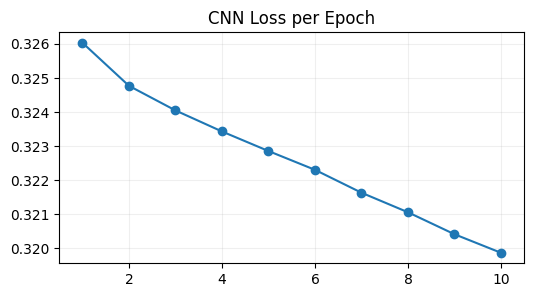

In [14]:
plt.figure(figsize=(6, 3))
plt.title('CNN Loss per Epoch')
plt.plot(np.linspace(1, 10, 10), loss_array, marker='o')
plt.grid(alpha=0.2)
plt.xticks([2, 4, 6, 8, 10])
plt.xlim(0.5, 10.5)
plt.show()

In [15]:
# ------------------------------
# Evaluation
# ------------------------------
model.eval()
with torch.no_grad():
    # Dynamically upsample to high-res patch size
    up_size = (Y_test.shape[2], Y_test.shape[3])
    Y_pred = model(X_test, up_size=up_size)

# ------------------------------
# Compute MSE
# ------------------------------
mse = ((Y_pred - Y_test) ** 2).mean().item()
print("CNN Test MSE:", mse)


# ------------------------------
# Spatial correlation function
# ------------------------------
def spatial_corr(y_true, y_pred):
    """
    Compute mean spatial correlation across patches.
    y_true, y_pred: (num_patches, 1, H, W)
    """
    y_true_flat = y_true.reshape(y_true.shape[0], -1)
    y_pred_flat = y_pred.reshape(y_pred.shape[0], -1)
    corrs = []
    for i in range(y_true.shape[0]):
        if np.std(y_true_flat[i]) > 0:  # skip constant patches
            corrs.append(np.corrcoef(y_true_flat[i], y_pred_flat[i])[0, 1])
    return np.nanmean(corrs)  # ignore NaNs


# Convert to numpy safely
Y_test_np = Y_test.cpu().numpy() if torch.is_tensor(Y_test) else Y_test
Y_pred_np = Y_pred.cpu().numpy() if torch.is_tensor(Y_pred) else Y_pred

corr = spatial_corr(Y_test_np, Y_pred_np)
print("CNN Test spatial correlation:", corr)

CNN Test MSE: 0.3212260603904724
CNN Test spatial correlation: 0.6559212320492078


In [74]:
# ------------------------------
# Bilinear baseline
# ------------------------------
# Only use the first channel of X_test as input to bilinear upsampling
Y_bilinear = F.interpolate(
    X_test[:, :, 0:1],
    size=(Y_test.shape[2], Y_test.shape[3]),
    mode='bilinear', align_corners=False
)

mse_bilinear = ((Y_bilinear - Y_test)**2).mean().item()
print("Bilinear upsampling MSE:", mse_bilinear)

Bilinear upsampling MSE: 2.597048044204712


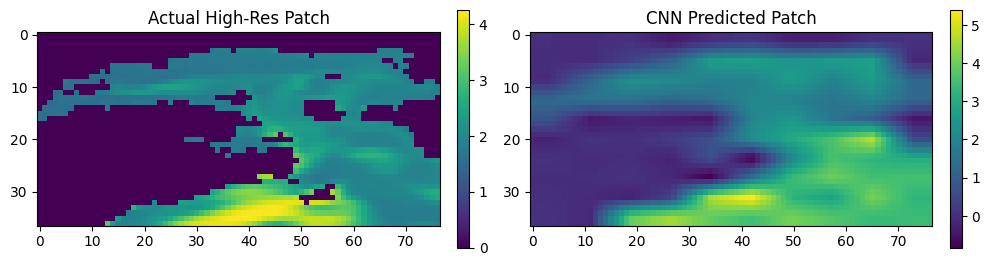

In [16]:
# ------------------------------
# Plot a random test patch vs prediction
# ------------------------------
sample_idx = np.random.randint(0, X_test.shape[0])
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(Y_test[sample_idx, 0].cpu().numpy(), cmap='viridis')
plt.title("Actual High-Res Patch")
plt.colorbar(fraction=0.0275, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(Y_pred[sample_idx, 0].cpu().numpy(), cmap='viridis')
plt.title("CNN Predicted Patch")
plt.colorbar(fraction=0.0275, pad=0.04)

plt.tight_layout()
plt.show()

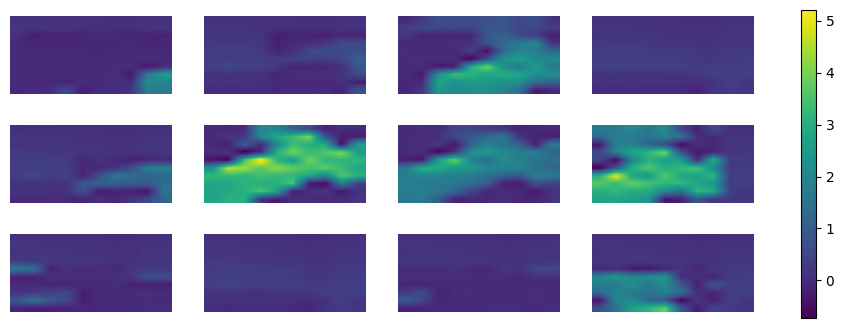

In [17]:
vmin = Y_pred[:12].min().item()
vmax = Y_pred[:12].max().item()

fig, axs = plt.subplots(3, 4, figsize=(12, 4))

for i, ax in enumerate(axs.flat):
    im = ax.imshow(Y_pred[i, 0].cpu(), cmap='viridis', vmin=vmin, vmax=vmax)
    ax.axis('off')

plt.colorbar(im, ax=axs.ravel().tolist())
plt.show()

In [23]:
X_test.shape, low_vars

(torch.Size([41796, 5, 10, 10]), ['hi', 'Tsfc', 'uvel', 'vvel'])

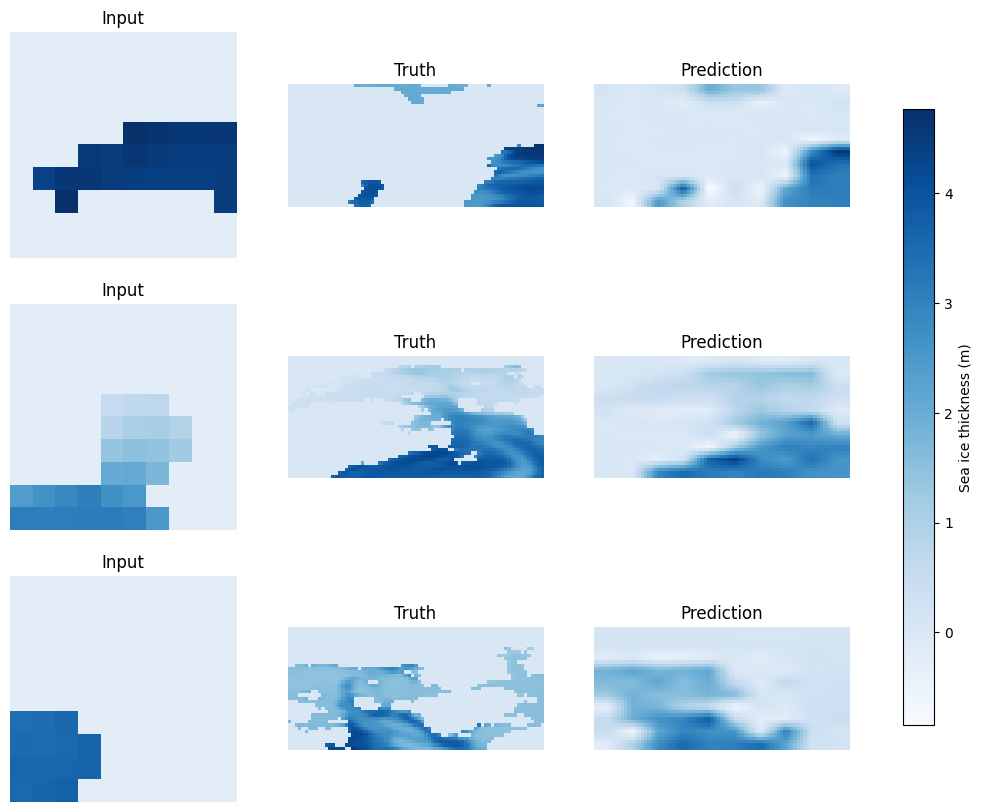

In [40]:
# idxs = np.random.choice(X_test.shape[0], 3, replace=False)
cmap = 'Blues'

fig, axs = plt.subplots(3, 3, figsize=(14, 10))

# determine shared color scale
vmin = min(
    X_test[idxs, 0].min().item(),
    Y_test[idxs, 0].min().item(),
    Y_pred[idxs, 0].min().item()
)

vmax = max(
    X_test[idxs, 0].max().item(),
    Y_test[idxs, 0].max().item(),
    Y_pred[idxs, 0].max().item()
)

im = None
for i, idx in enumerate(idxs):

    im = axs[i, 0].imshow(X_test[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 0].set_title("Input")

    axs[i, 1].imshow(Y_test[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 1].set_title("Truth")

    axs[i, 2].imshow(Y_pred[idx, 0].cpu(), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[i, 2].set_title("Prediction")

    for j in range(3):
        axs[i, j].axis('off')

# shared colorbar
fig.colorbar(im, ax=axs, shrink=0.8, label='Sea ice thickness (m)')

plt.show()

- Idea 1: Train on only informative patches

```
mask = Y_patches.mean(dim=(2, 3)) > 0.05
X_patches = X_patches[mask]
Y_patches = Y_patches[mask]
```

- Idea 2: Weight the loss by ice presence

```
ice_mask = (Y_true > 0)
loss_new = ((Y_pred - Y_true)**2 * (1 + ice_mask)).mean()
```

- Idea 3: Add ice presence as input channel

- Idea 4: Interpolate for base field and have CNN do finer corrections so the fallback solution becomes: residual ≈ 0

```
Y_pred = bilinear(X) + CNN(X)
base = F.interpolate(x[:,0:1], size=up_size, mode="bilinear", align_corners=False)
residual = self.cnn(x)

return base + residual
```

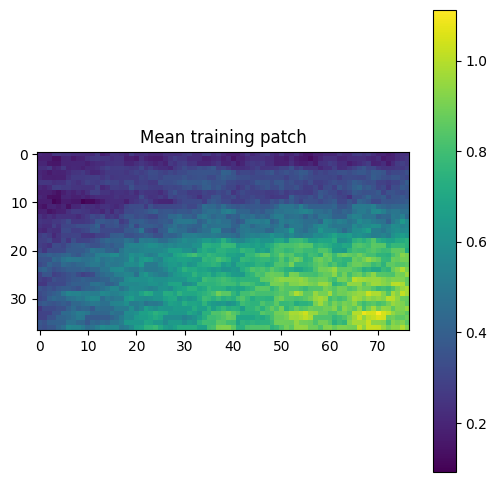

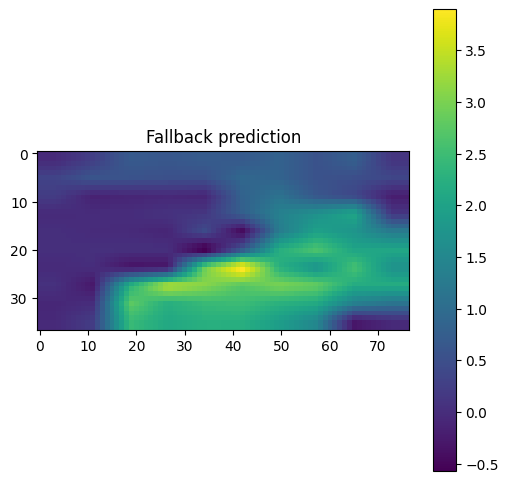

In [19]:
train_mean = Y_patches.mean(dim=0)

plt.imshow(train_mean[0].cpu(), cmap='viridis')
plt.title("Mean training patch")
plt.colorbar()
plt.show()

plt.imshow(Y_pred[2, 0].cpu(), cmap='viridis')
plt.title("Fallback prediction")
plt.colorbar()
plt.show()